In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
file_path = "../../dataset/prepared/final_preprocessedv2_8PCs.csv"
df = pd.read_csv(file_path)

# Optional: Preview the first few rows
df.head()


,FP_IDX,FP_AMP1,FP_AMP2,CIR_PWR,MAX_NOISE,RXPACC,FRAME_LEN,CIR_PC1,CIR_PC2,CIR_PC3,CIR_PC4,CIR_PC5,CIR_PC6,RANGE
0,745.0,18712.0,10250.0,11855.0,967.0,611.0,39.0,-9.034594,21.247168,2.683200,12.696970,3.976160,-2.563228,3.90
1,749.0,11239.0,6313.0,18968.0,1133.0,447.0,27.0,25.389144,-55.417879,34.631625,20.236273,-0.880709,-2.820648,0.66
2,746.0,4355.0,5240.0,14699.0,894.0,723.0,27.0,-19.931322,-18.167155,8.725183,10.258672,3.037047,0.307626,7.86
3,750.0,8502.0,8416.0,8748.0,1127.0,1024.0,39.0,-38.491470,-15.676134,2.714543,1.786545,2.430626,1.966707,3.48
4,746.0,17845.0,18095.0,11380.0,1744.0,276.0,27.0,58.915081,55.849609,-15.308050,8.927246,2.424912,22.160814,1.19


Check linearity of data to determine is linear regression is appropriate

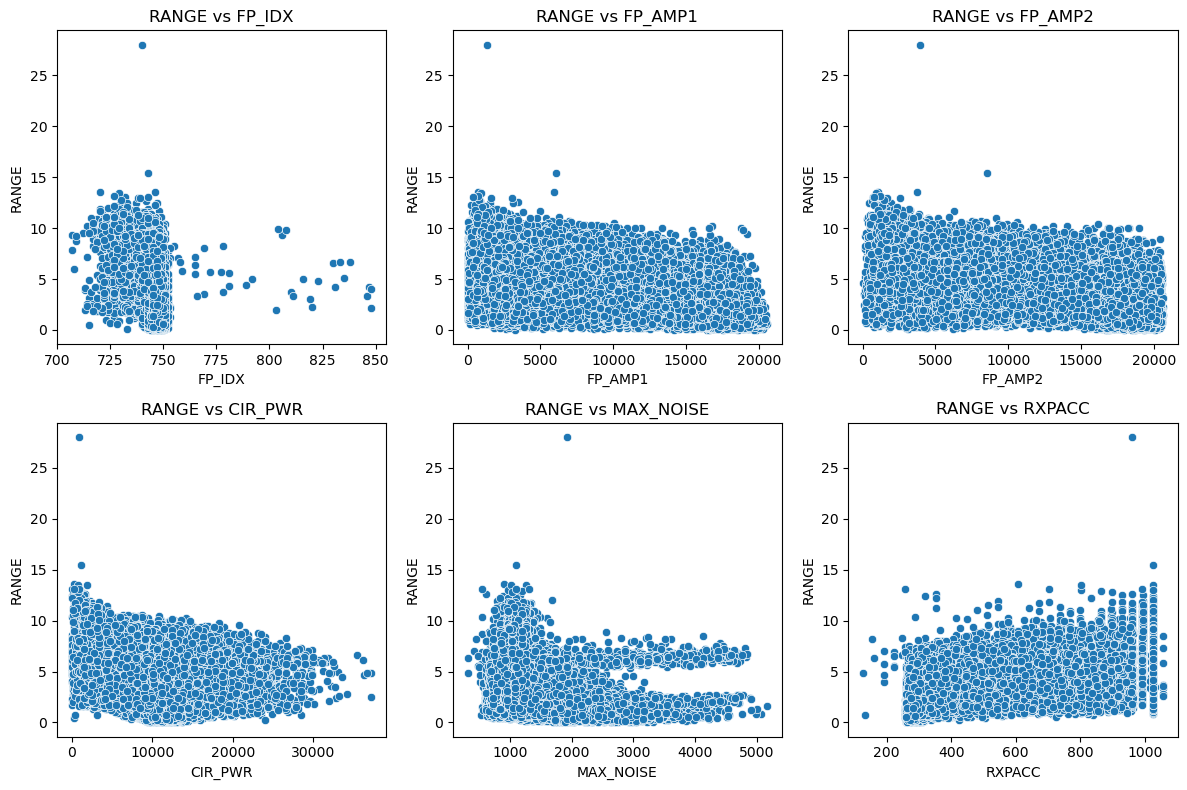

RANGE        1.000000
RXPACC       0.626349
CIR_PC4      0.047454
CIR_PC5     -0.002252
CIR_PC6     -0.020893
FRAME_LEN   -0.048082
CIR_PC2     -0.063041
CIR_PC3     -0.064315
MAX_NOISE   -0.260065
CIR_PWR     -0.263718
FP_IDX      -0.321809
FP_AMP1     -0.459196
FP_AMP2     -0.479689
CIR_PC1     -0.655803
Name: RANGE, dtype: float64


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df is your dataset
features = ["FP_IDX", "FP_AMP1", "FP_AMP2", "CIR_PWR", "MAX_NOISE", "RXPACC"]

plt.figure(figsize=(12, 8))
for i, feature in enumerate(features):
    plt.subplot(2, 3, i+1)
    sns.scatterplot(x=df[feature], y=df["RANGE"])
    plt.xlabel(feature)
    plt.ylabel("RANGE")
    plt.title(f"RANGE vs {feature}")

plt.tight_layout()
plt.show()

correlation_matrix = df.corr()
print(correlation_matrix["RANGE"].sort_values(ascending=False))




In [3]:
X = df.drop(columns=["RANGE"])
y = df["RANGE"]


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=111)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (29400, 13)
X_test shape: (12600, 13)


Linear Regression Performance on Test Set:
Mean Absolute Error: 1.3372
Mean Squared Error: 2.9438
R-squared: 0.4713
Root Mean Squared Error: 1.7157


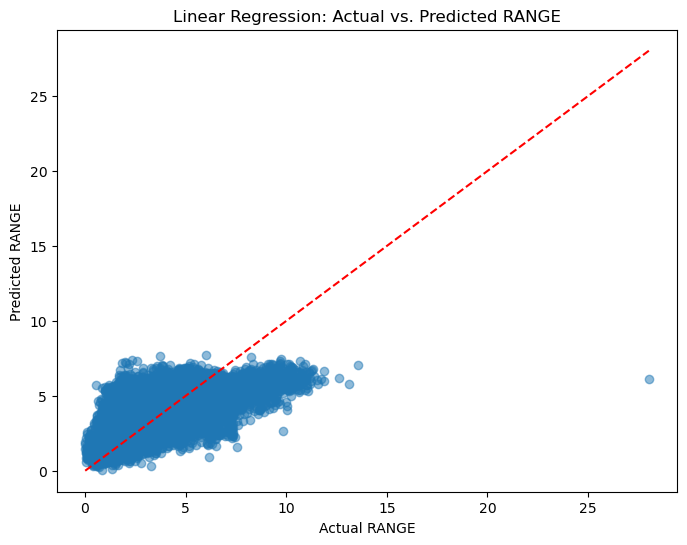

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt

# Create and train the Linear Regression model
linreg = LinearRegression()
linreg.fit(X_train, y_train)

# Predict on the test set
y_pred = linreg.predict(X_test)

# Evaluate performance
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)

print("Linear Regression Performance on Test Set:")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R-squared: {r2:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f}")

# Plot Actual vs. Predicted values
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual RANGE")
plt.ylabel("Predicted RANGE")
plt.title("Linear Regression: Actual vs. Predicted RANGE")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()


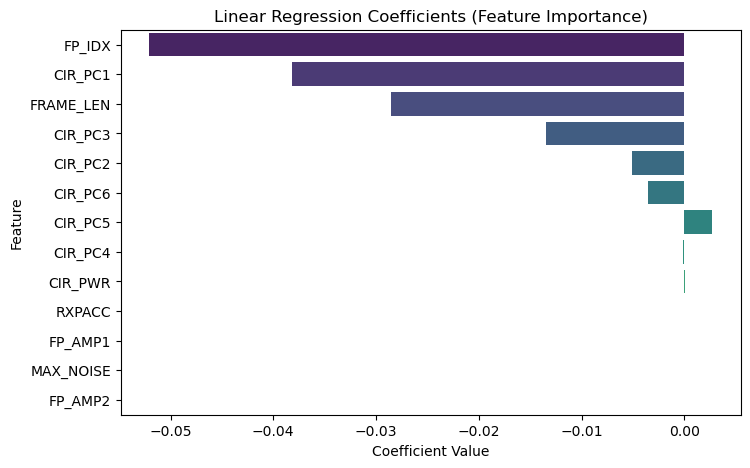

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming 'linreg' is your trained LinearRegression model
# and that X_train is your feature matrix with the target column removed.
# If you haven't dropped "RANGE" from X, consider doing so for this analysis.
# For example:
# X_train_no_range = X_train.drop(columns=["RANGE"])
# Otherwise, if X_train already excludes RANGE, then:
X_train_no_range = X_train  # Ensure that target "RANGE" is not in X_train

# Extract coefficients from the linear regression model
coefficients = pd.Series(linreg.coef_, index=X_train_no_range.columns)
# Sort coefficients by absolute value (largest impact first)
coefficients_sorted = coefficients.reindex(coefficients.abs().sort_values(ascending=False).index)

plt.figure(figsize=(8,5))
ax = sns.barplot(x=coefficients_sorted.values,
                 y=coefficients_sorted.index,
                 hue=coefficients_sorted.index,
                 palette="viridis",
                 dodge=False)
if ax.get_legend() is not None:
    ax.get_legend().remove()

plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Linear Regression Coefficients (Feature Importance)")
plt.show()


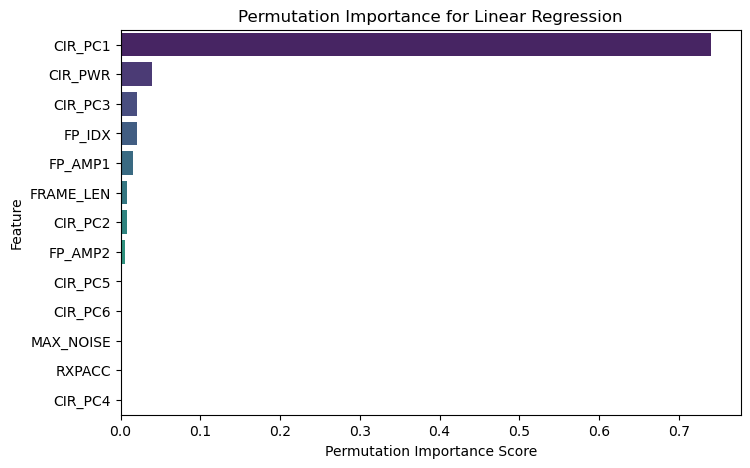

In [7]:
from sklearn.inspection import permutation_importance
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate permutation importance on the test set
# (Make sure your X_test doesn't include the target column "RANGE" if needed)
X_test_no_range = X_test  # Ensure "RANGE" is dropped if necessary

r = permutation_importance(linreg, X_test_no_range, y_test, n_repeats=10, random_state=111)
perm_importances = pd.Series(r.importances_mean, index=X_test_no_range.columns).sort_values(ascending=False)

plt.figure(figsize=(8,5))
ax = sns.barplot(x=perm_importances.values, 
                 y=perm_importances.index, 
                 hue=perm_importances.index, 
                 palette="viridis", 
                 dodge=False)
if ax.get_legend() is not None:
    ax.get_legend().remove()

plt.xlabel("Permutation Importance Score")
plt.ylabel("Feature")
plt.title("Permutation Importance for Linear Regression")
plt.show()


(I have no idea what to do with this. I did not add this to report -Felix)
- Based on feature importance **FP_AMP2, CIR_PC7, CIR_PWR,CIR_PC5** (for dataset final_preprocessed_8PCs.cvs)
  - Mean Absolute Error: 0.8960749183539303
  - Mean Squared Error: 1.3181932499097324
  - R-squared: 0.5210355274662717
  
- Based on feature importance, can remove **MAX_NOISE,CIR_PC5/7, RXPACC** (for dataset final_preprocessed_8PCs_both.cvs)
  - Mean Absolute Error: 1.249731593271678
  - Mean Squared Error: 2.6274648674134844
  - R-squared: 0.5281184811391348

- Based on feature importance, can remove **CIR5/7, FP_AMP2, RXPACC** (for dataset final_preprocessed_8PCs_both_all.cvs)

  - Mean Absolute Error: 1.2432953540338854
  - Mean Squared Error: 2.609175616196198
  - R-squared: 0.5314031528964157